# Exploratory Data Analysis

## 1. Loading Data & Overview

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('tracks2026.csv')
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


Each row is a track. There are 17 different columns. Three columns (track_id, explicit and track_genre) contain something else than numbers, rest contain numbers. Track id is the id of the track, so it can be used to identify the track.

## 2. Categorical Variables

In [3]:
df['explicit'].value_counts(dropna=False)


explicit
False    1777
True      223
Name: count, dtype: int64

In [4]:
df['track_genre'].value_counts(dropna=False)

track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64

Explicit and track_genre -columns can be left as they are as they do not contain any missing values. Explicit-column is unbalanced which needs to be considered later on in the modelling part.

In [5]:
df['mode'].value_counts(dropna=False)

mode
1    1275
0     725
Name: count, dtype: int64

In [6]:
df['key'].value_counts(dropna=False)

key
0     243
1     193
7     192
9     187
5     184
2     173
8     157
11    154
6     152
4     147
10    143
3      75
Name: count, dtype: int64

In [7]:
df['time_signature'].value_counts(dropna=False)

time_signature
4    1838
3     115
1      27
5      20
Name: count, dtype: int64

Column 'mode' seems to be categorical, containing only values 0 or 1. Column 'key' is Pitch class map of integers 0-11 and also categorical. Column 'time_signature' is also categorical and is heavily focused in value of 4 (almost all the data).

## 3. Numeric Variables

In the following, the numeric columns will be examined for distributions, outliers, and missing values.

In [8]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,1960.000000,2000.000000,1960.000000,1960.000000,2000.000000,1961.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1960.000000,2000.000000
mean,39.805102,217806.433000,0.635897,0.632489,5.295500,400.575884,0.637500,0.078466,0.297378,0.030269,0.180715,0.539963,120.040092,3.912000
std,29.245904,56804.759189,0.138298,0.189087,3.567148,18065.717039,0.480842,0.076223,0.279793,0.119946,0.149938,0.236062,28.520528,0.425848
min,0.000000,60000.000000,0.185000,0.090900,0.000000,-21.089000,0.000000,0.022100,0.000007,0.000000,0.009860,0.035900,51.037000,1.000000
25%,1.750000,181210.000000,0.548000,0.507750,2.000000,-8.988000,0.000000,0.034475,0.052475,0.000000,0.093775,0.353000,96.956000,4.000000
50%,45.000000,211346.000000,0.646000,0.644000,5.000000,-6.924000,1.000000,0.047500,0.195500,0.000007,0.121000,0.536000,118.711500,4.000000
75%,65.000000,246069.750000,0.738000,0.780000,8.000000,-5.390000,1.000000,0.084950,0.490250,0.000638,0.221250,0.730000,139.746250,4.000000
max,100.000000,561133.000000,0.953000,0.996000,11.000000,800000.000000,1.000000,0.515000,0.990000,0.962000,0.986000,0.990000,205.895000,5.000000


Columns 'popularity', 'danceability', 'energy', 'loudness' and 'tempo' have missing values. They all seem to be in the same rows.

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print(missing_summary.to_string())
print(f"\nTotal rows with at least one NaN: {df.isnull().any(axis=1).sum()}")


              Missing Count  Missing %
popularity               40       2.00
danceability             40       2.00
energy                   40       2.00
loudness                 39       1.95
tempo                    40       2.00

Total rows with at least one NaN: 40


In [10]:
df_nans = df[df["popularity"].isnull() | df["danceability"].isnull() | df["energy"].isnull() | df["loudness"].isnull() | df["tempo"].isnull() ]
df_nans

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
29,1n5gnI3Wue9WBpYFOIQNh1,NaN,341386,False,NaN,NaN,11,NaN,1,0.3310,0.237000,0.000000,0.0791,0.6760,NaN,4,pop
56,0hcvwkxhxlIRdeLb1dWJBT,NaN,245187,False,NaN,NaN,5,NaN,0,0.0372,0.102000,0.000000,0.2290,0.6020,NaN,4,synth-pop
65,1PYCOTJ2g3WJkFsgLlzIEW,NaN,185133,True,NaN,NaN,8,NaN,1,0.0502,0.512000,0.000000,0.0638,0.9660,NaN,4,r-n-b
99,08HJeHs0U9iSbDWX0sWIem,NaN,169371,False,NaN,NaN,9,NaN,1,0.0999,0.739000,0.000000,0.0919,0.3160,NaN,4,r-n-b
128,08EzywoYzT4unsQXslM9RA,NaN,268560,False,NaN,NaN,5,NaN,1,0.0262,0.257000,0.000013,0.1780,0.8700,NaN,4,synth-pop
254,6IdUSDkIkBP7ZmTIZrZiVV,NaN,135053,True,NaN,NaN,11,NaN,1,0.0762,0.001610,0.098500,0.1060,0.4050,NaN,4,hip-hop
275,52gGYiO7QQtQMpvF8OBHDV,NaN,213573,False,NaN,NaN,9,NaN,1,0.0299,0.513000,0.000002,0.0880,0.8400,NaN,4,r-n-b
353,1QZRCi2Z1DQQaR6bGAzhtN,NaN,224444,False,NaN,NaN,11,NaN,0,0.1170,0.256000,0.000000,0.6140,0.6620,NaN,4,hip-hop
374,2qPNdVlqZl1cYqsNc3MXnA,NaN,134351,False,NaN,NaN,7,NaN,1,0.2090,0.043300,0.000029,0.0752,0.7560,NaN,4,hip-hop
450,7hUxzSsK2OHjeKWkzeArIU,NaN,248006,False,NaN,NaN,2,NaN,1,0.0330,0.430000,0.000000,0.1510,0.2420,NaN,4,pop


Let us look the numerical values in two parts, first columns 'popularity','duration_ms', 'danceability', 'energy', 'loudness', 'speechiness'.

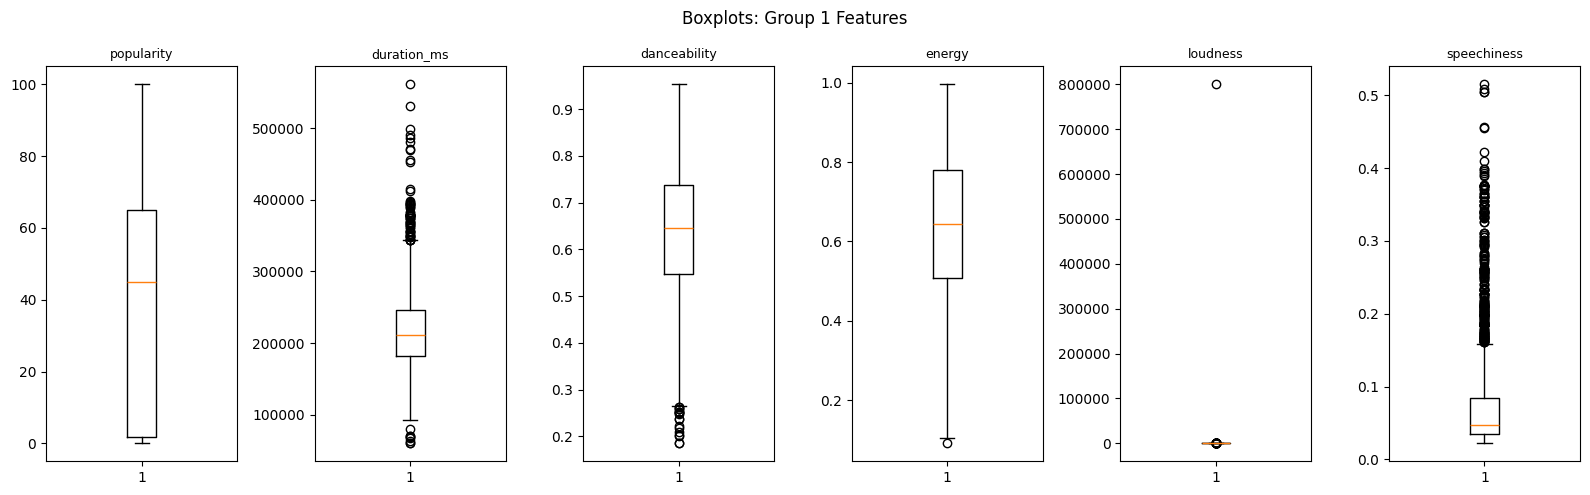

In [11]:
import matplotlib.pyplot as plt

cols_group1 = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness']
fig, axes = plt.subplots(1, len(cols_group1), figsize=(16, 5))
for ax, col in zip(axes, cols_group1):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
fig.suptitle('Boxplots: Group 1 Features', fontsize=12)
plt.tight_layout()
plt.show()


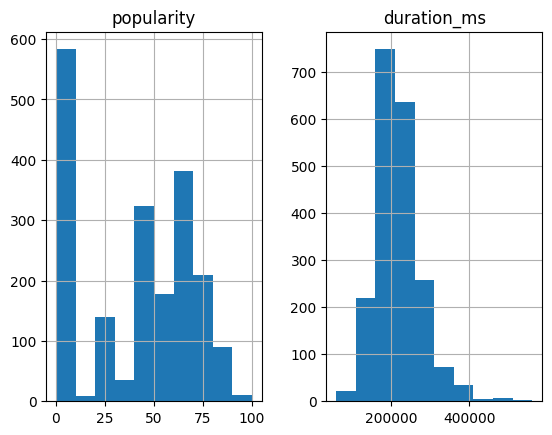

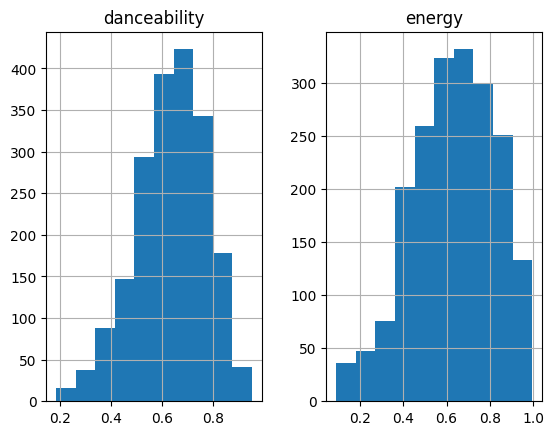

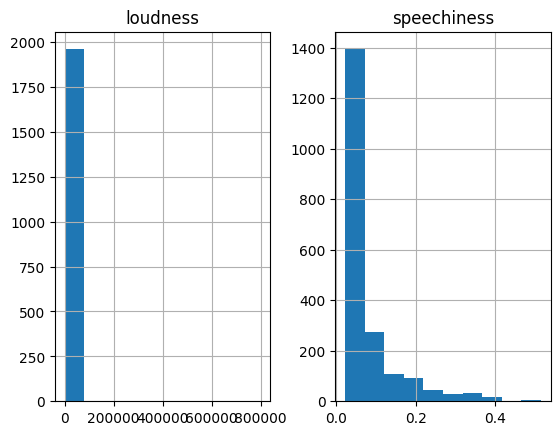

In [12]:
import matplotlib.pyplot as plt
df[['popularity','duration_ms']].hist()
plt.show()
df[['danceability', 'energy']].hist()
plt.show()
df[['loudness', 'speechiness']].hist()
plt.show()

As can be seen in the boxplot, duration, danceability, energy, loudness and speechines all have outliers. Also the scale of duration is far more dominant than other features. All of these columns are at least a bit skewed, which can be seen in the histograms.

In [13]:
df[df['loudness']> 0]

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1289,39ujbBjTwwqUFySaCYDMMT,NaN,178604,False,NaN,NaN,1,800000.0,0,0.0851,0.485,0.0,0.318,0.49,NaN,4,pop


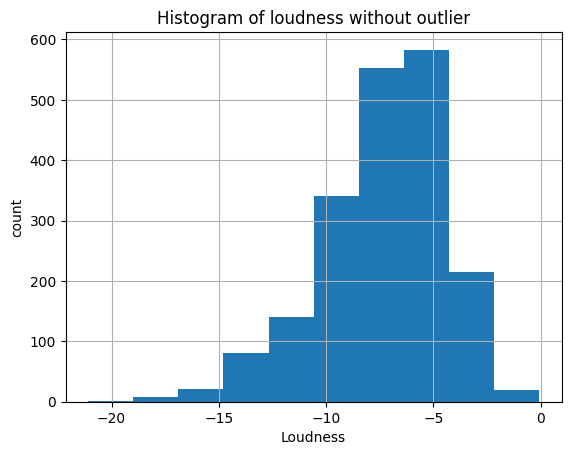

In [14]:
import matplotlib.pyplot as plt
loudness = df[df['loudness']<=0]['loudness'].to_numpy()
plt.hist(loudness)
plt.title('Histogram of loudness without outlier')
plt.xlabel('Loudness')
plt.ylabel('count')
plt.grid()
plt.show()

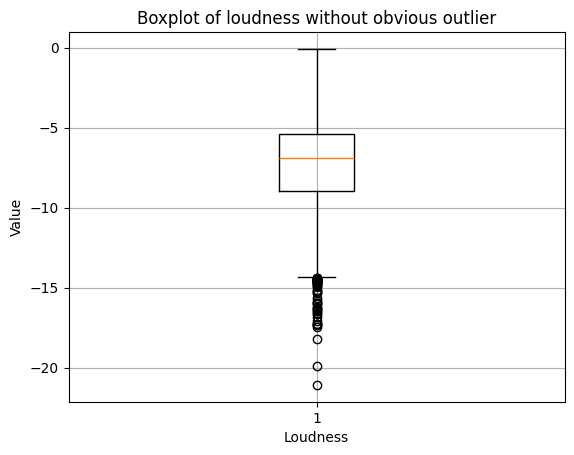

In [15]:
plt.boxplot(loudness)
plt.title('Boxplot of loudness without obvious outlier')
plt.xlabel('Loudness')
plt.ylabel('Value')
plt.grid()
plt.show()

There seems to be one incorrect datapoint in the loudness column (record 1289), as other values are negative and the value of the record in question is 800000.

Suggestion for data preparation of the columns 'popularity','duration_ms', 'danceability', 'energy', 'loudness', 'speechiness':
Drop the record of 1289.
For column popularity, use standard scaler and log transformation.
For columns rest columns, use robust scaler and log transformation.

Let us next explore columns 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'.

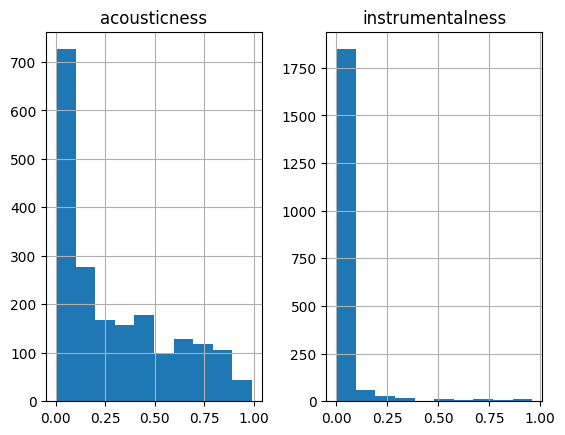

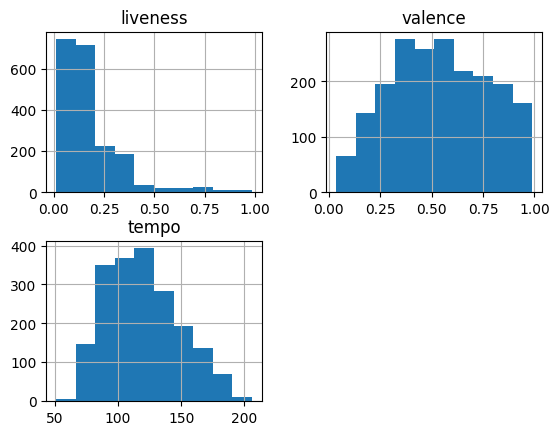

In [16]:
df[['acousticness', 'instrumentalness']].hist()
plt.show()
df[['liveness', 'valence', 'tempo']].hist()
plt.show()

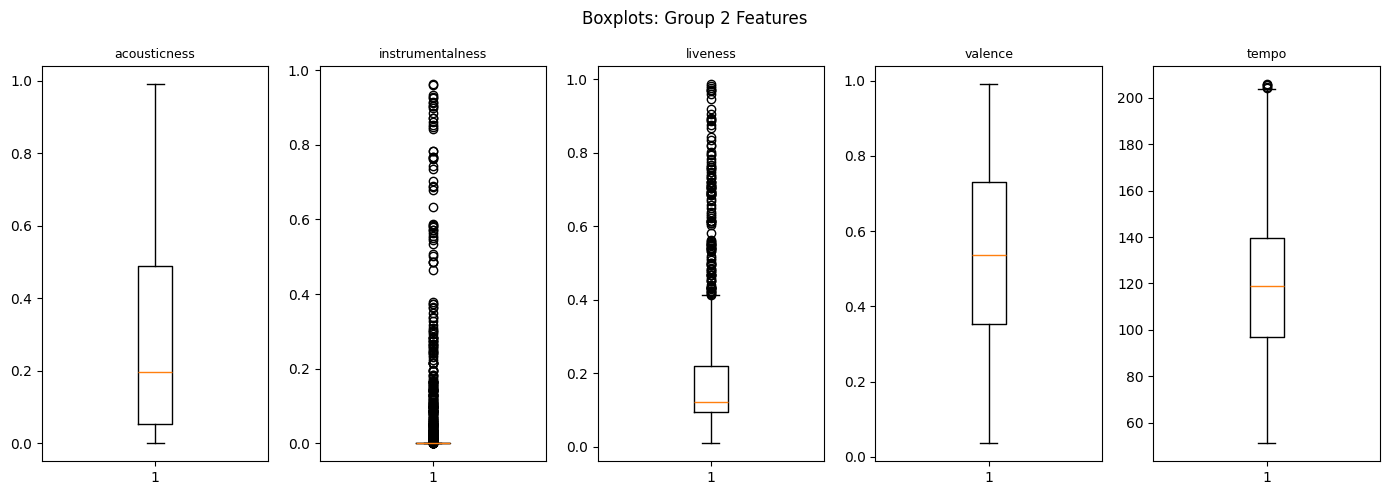

In [17]:
cols_group2 = ['acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
fig, axes = plt.subplots(1, len(cols_group2), figsize=(14, 5))
for ax, col in zip(axes, cols_group2):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
fig.suptitle('Boxplots: Group 2 Features', fontsize=12)
plt.tight_layout()
plt.show()


As can be seen, instrumentalness, liveness and tempo have outliers. All of these columns are at least a bit skewed but acousticness, instrumentalness and liveness the most.

Suggestion for data preparation:
For acousticness and valence, use standard scaler and log transformation.
For rest of the columns, use robust scaler and log transformation.

## 4. Correlation Analysis

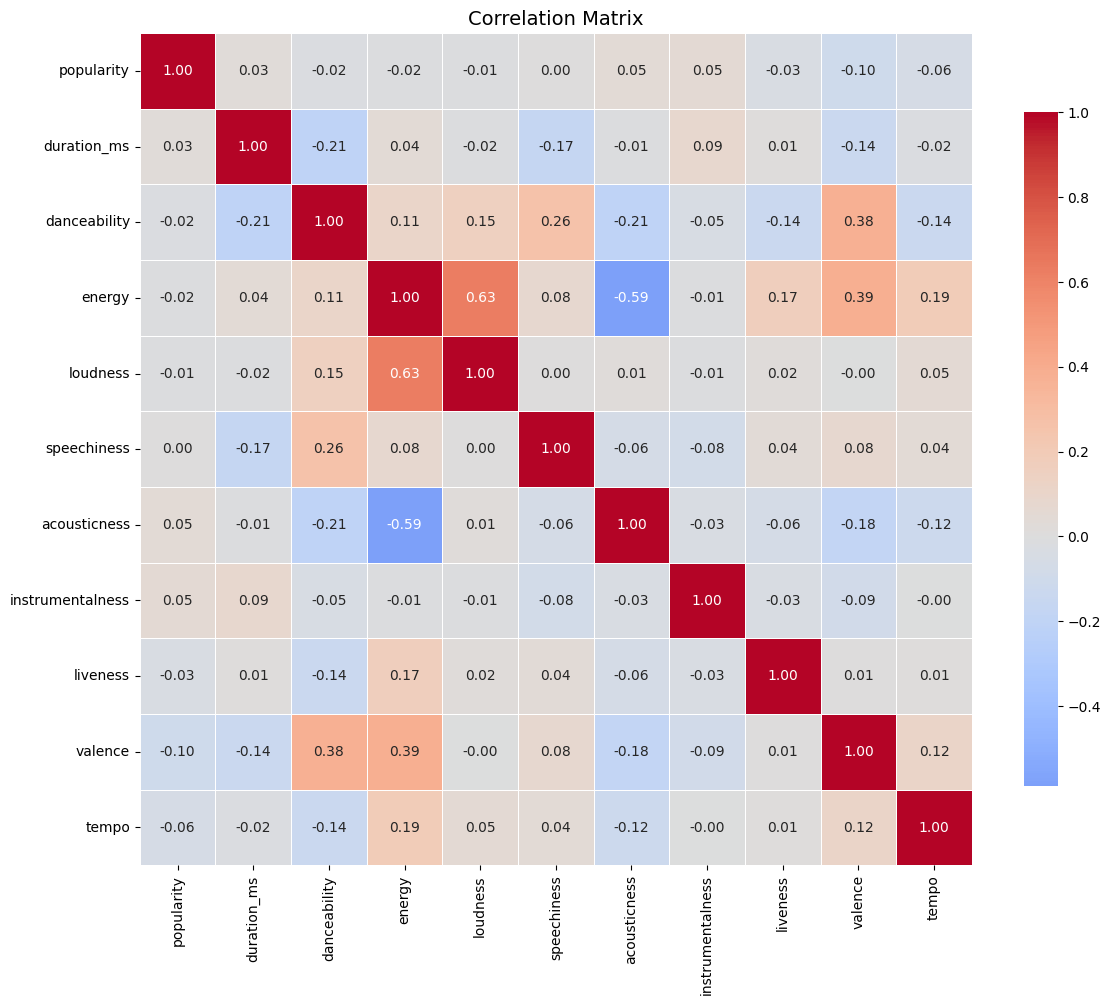

In [19]:
import seaborn as sns

numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

As can be seen, the highest correlation between the variables is between loudnes and energy (0.632503). This is somewhat understandable as the more loud the music is, the more it physically feels, and that may lead to being more energized.

Lowest correlation is between acoustiness and energy (-0.588686). This is also somewhat explainable, as acoustic songs tend to be a bit slower and thus not so energized songs.

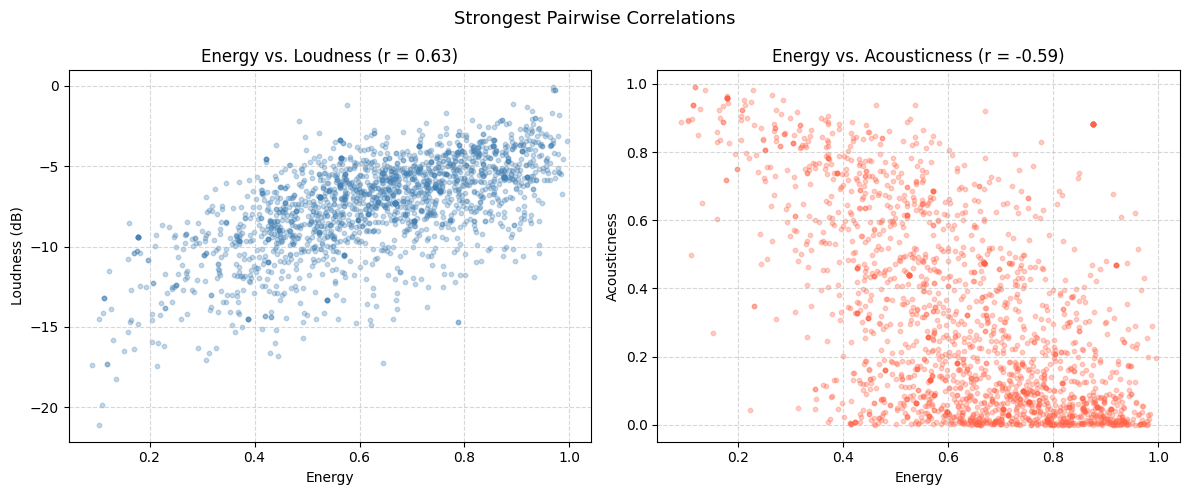

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_clean = df[df['loudness'] <= 0].dropna(subset=['energy', 'loudness', 'acousticness'])

axes[0].scatter(df_clean['energy'], df_clean['loudness'], alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Loudness (dB)')
axes[0].set_title('Energy vs. Loudness (r = 0.63)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(df_clean['energy'], df_clean['acousticness'], alpha=0.3, s=10, color='tomato')
axes[1].set_xlabel('Energy')
axes[1].set_ylabel('Acousticness')
axes[1].set_title('Energy vs. Acousticness (r = -0.59)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Strongest Pairwise Correlations', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Genre Analysis
The following section examines differences between genres in terms of popularity and audio features.

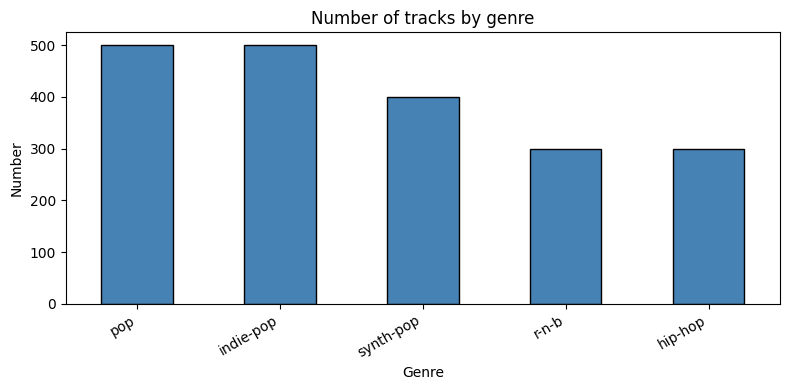

In [21]:
plt.figure(figsize=(8, 4))
df['track_genre'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of tracks by genre')
plt.xlabel('Genre')
plt.ylabel('Number')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

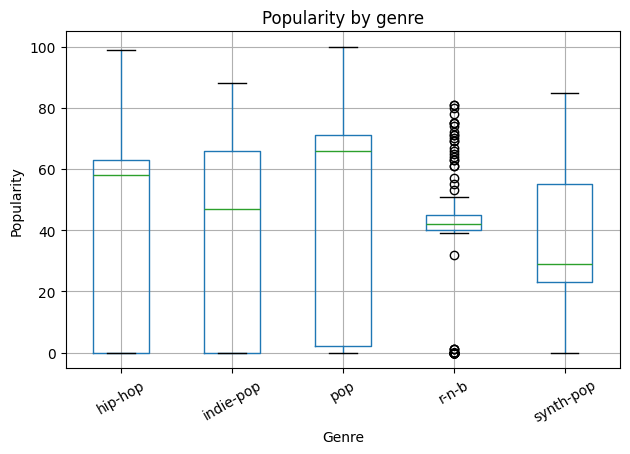

In [22]:
plt.figure(figsize=(10, 5))
df.boxplot(column='popularity', by='track_genre', rot=30)
plt.title('Popularity by genre')
plt.suptitle('')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

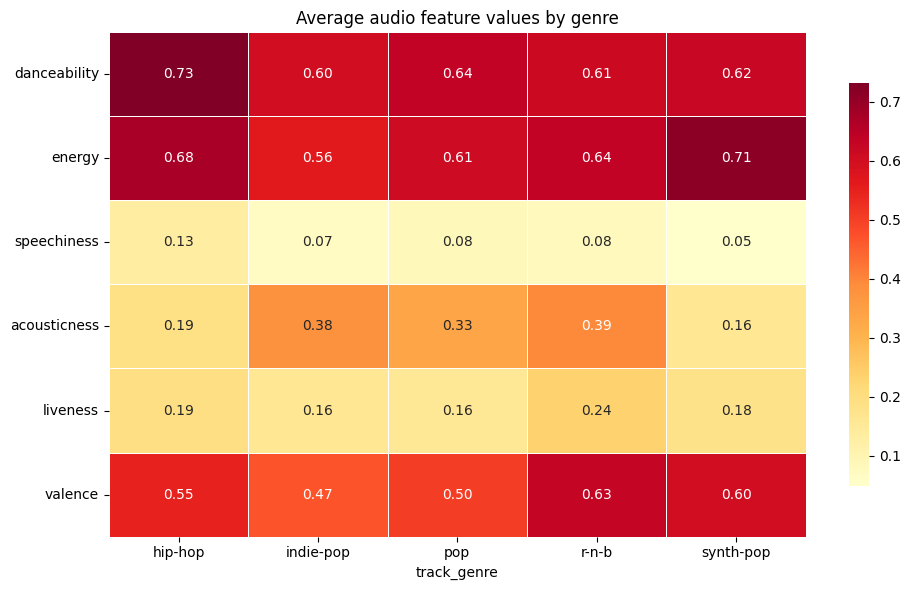

In [23]:
feature_cols = ['danceability', 'energy', 'speechiness',
                'acousticness', 'liveness', 'valence']

genre_means = df.groupby('track_genre')[feature_cols].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(genre_means.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Average audio feature values by genre')
plt.tight_layout()
plt.show()

/tmp/ipykernel_25871/3789738559.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_valid, x='track_genre', y=feat, ax=ax,
/tmp/ipykernel_25871/3789738559.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
/tmp/ipykernel_25871/3789738559.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_valid, x='track_genre', y=feat, ax=ax,
/tmp/ipykernel_25871/3789738559.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.ge

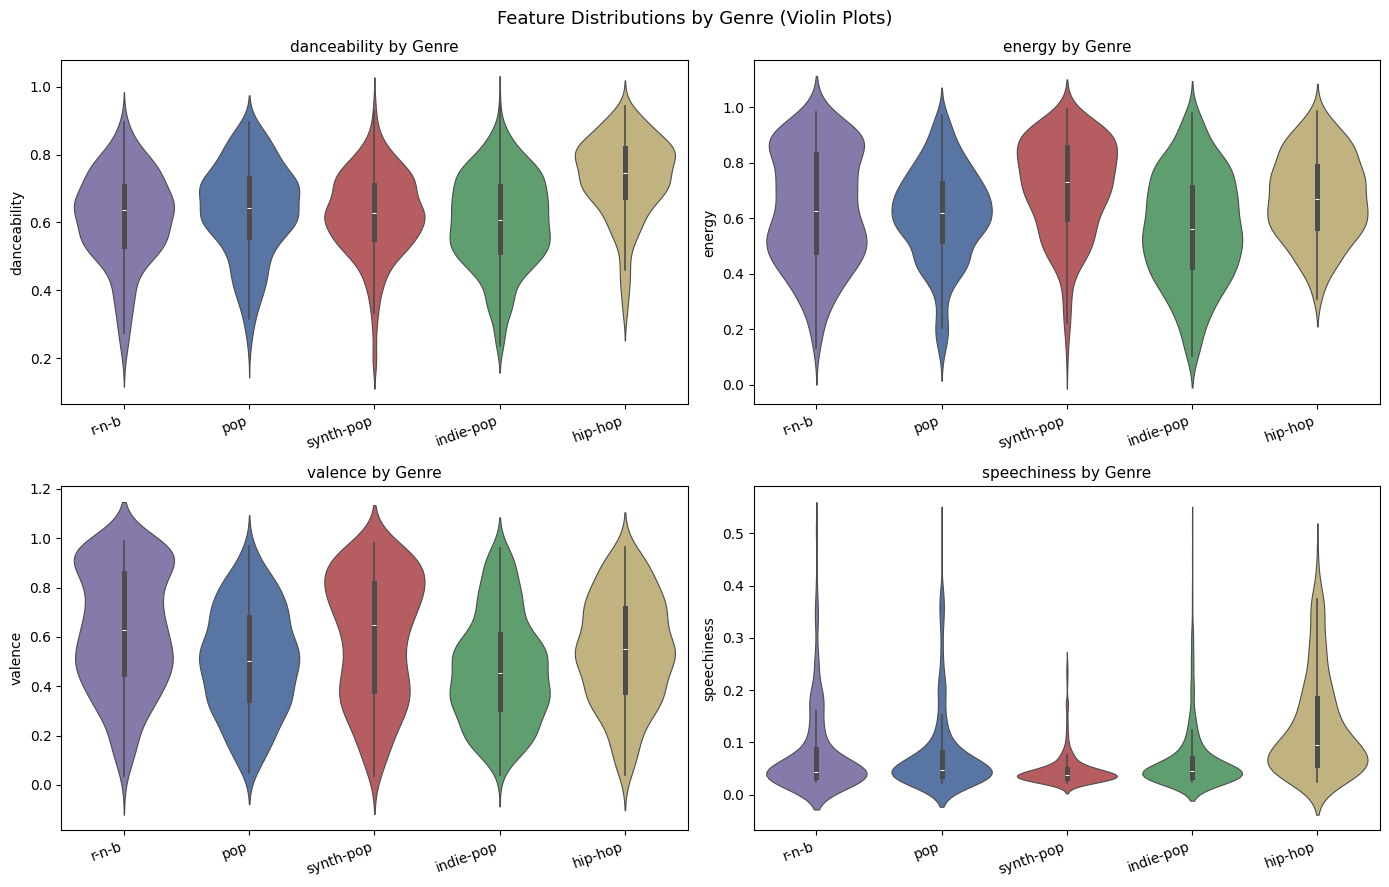

In [24]:
key_features = ['danceability', 'energy', 'valence', 'speechiness']
df_valid = df.dropna(subset=key_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
palette = {'pop': '#4C72B0', 'indie-pop': '#55A868', 'synth-pop': '#C44E52',
           'r-n-b': '#8172B2', 'hip-hop': '#CCB974'}

for ax, feat in zip(axes, key_features):
    sns.violinplot(data=df_valid, x='track_genre', y=feat, ax=ax,
                   palette=palette, inner='box', linewidth=0.8)
    ax.set_title(f'{feat} by Genre', fontsize=11)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Feature Distributions by Genre (Violin Plots)', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Conclusion

### Summary of Key Findings

**Dataset structure & quality.**  
The dataset contains 2,000 tracks described by 17 columns — one string identifier (`track_id`), two binary/categorical features (`explicit`, `mode`), three ordinal-categorical features (`key`, `time_signature`, `track_genre`), and 11 continuous audio features.  
Forty rows (2 %) have a coordinated block of NaN values across `popularity`, `danceability`, `energy`, `loudness`, and `tempo`, indicating a systematic acquisition failure rather than random missingness. Row 1289 additionally contains a loudness value of 800,000 — an obvious data entry error. Both issues must be resolved before any modelling step.

**Distribution characteristics.**  
Most continuous features are right-skewed or bimodal (e.g. `acousticness`, `instrumentalness`, `speechiness`), and several (notably `duration_ms` and `liveness`) have long upper tails. `popularity` is particularly heavy near zero, suggesting a large number of low-profile tracks alongside a smaller group of chart hits. These distributional properties imply that distance-based models and linear models will benefit substantially from log-transformation and robust scaling.

**Correlations.**  
The two strongest linear relationships are `energy ↔ loudness` (r = 0.63) and `energy ↔ acousticness` (r = −0.59). These are intuitive: louder tracks feel more energetic, and acoustic recordings are typically quieter and more mellow. All other feature pairs show only weak-to-moderate correlations (|r| < 0.40), suggesting that the feature space retains meaningful multi-dimensional variance — a good sign for both clustering and regression.

**Genre differences.**  
Hip-hop stands out through elevated `speechiness` and relatively high `danceability`. R&B shares the danceability profile but with lower speechiness. Synth-pop and indie-pop overlap heavily on most features, which will likely make them difficult to distinguish by audio features alone. Pop is the most heterogeneous genre in terms of `popularity` spread. The imbalance in genre counts (500 pop / indie-pop vs. 300 r-n-b / hip-hop) should be accounted for when evaluating classifiers.

---

### Implications for Clustering (Task 3.2)

1. **Feature selection.** The correlated pair `energy`–`loudness` effectively carries redundant information; retaining both may over-weight that dimension in distance-based clustering. Consider either dropping one or applying PCA to decorrelate the feature space before clustering.
2. **Scaling is mandatory.** K-Means and DBSCAN are sensitive to feature scale. Given the skewed distributions, robust scaling (or min-max after outlier removal) is preferable to standard scaling for most features.
3. **Expected cluster structure.** Given the genre-level feature differences — particularly the speechiness gap between hip-hop and the pop variants — audio features alone should support the discovery of at least 2–3 musically meaningful clusters. However, because synth-pop and indie-pop overlap strongly, a hard partition into 5 genre-aligned clusters is unlikely to be recoverable without additional features.
4. **Outlier sensitivity.** DBSCAN in particular will be affected by the extreme outliers in `instrumentalness`, `liveness`, and `duration_ms`. These should be clipped or removed before clustering, or an appropriate `eps` and `min_samples` should be chosen to treat them as noise points.

---

### Implications for Predictive Analysis (Task 3.3)

1. **Predicting popularity.** `popularity` has a weak linear relationship with all other individual features (max |r| ≈ 0.10 with `valence`). This suggests that a linear model will underperform unless feature interactions or non-linear transformations are introduced. Tree-based models (Random Forest, Gradient Boosting) are likely to perform better.
2. **Class imbalance for `explicit`.** Only 11 % of tracks are marked explicit. Any classifier predicting `explicit` must use stratified splits and class-weighted loss; accuracy alone is a misleading metric here.
3. **Genre as a predictor or target.** The genre-level differences in `speechiness`, `danceability`, and `energy` suggest that genre is a meaningful predictor for popularity within a class, and also a reasonable classification target in its own right. Encoding `track_genre` as a one-hot feature may improve regression models for popularity.
4. **Drop or impute NaN rows consistently.** The 40 rows with missing audio features should be excluded from any supervised task that uses those features. Row 1289 must be removed or its loudness value corrected prior to any analysis.
